# graph Laplacian

In [29]:
import numpy as np

K = np.array([
    [1, -1, 0, 0],
    [1, 0, -1, 0],
    [0, 1, -1, 0],
    [1, 0, 0, -1],
])

L = K.T @ K 

L

array([[ 3, -1, -1, -1],
       [-1,  2, -1,  0],
       [-1, -1,  2,  0],
       [-1,  0,  0,  1]])

change the edge direction, and re-calculate graph Laplacian

In [30]:
K = np.array([
    [-1, 1, 0, 0],
    [-1, 0, 1, 0],
    [0, 1, -1, 0],
    [-1, 0, 0, 1],
])

L = K.T @ K 

L

array([[ 3, -1, -1, -1],
       [-1,  2, -1,  0],
       [-1, -1,  2,  0],
       [-1,  0,  0,  1]])

# Spectral clustering

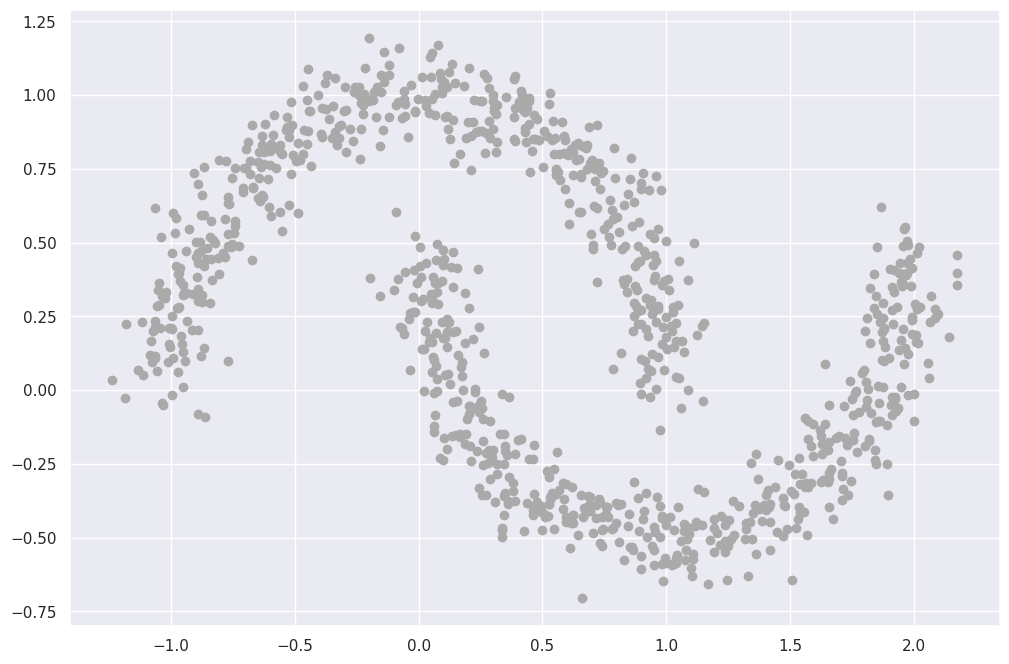

In [28]:
import numpy as np

from sklearn.datasets import make_circles, make_moons
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import pairwise_distances
import networkx as nx
import seaborn as sns
from scipy import sparse
from warnings import catch_warnings
from warnings import simplefilter
from matplotlib import pyplot as plt

%matplotlib inline

params = {'legend.fontsize': 20,
          'legend.handlelength': 2,
          'figure.figsize':(12, 8)
          }
plt.rcParams.update(params)

sns.set()

# X, clusters = make_circles(n_samples=1000, noise=.05, factor=.5, random_state=0)
X, clusters = make_moons(n_samples=1000,noise=0.08)
plt.scatter(X[:,0], X[:,1], c='#aaa')

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


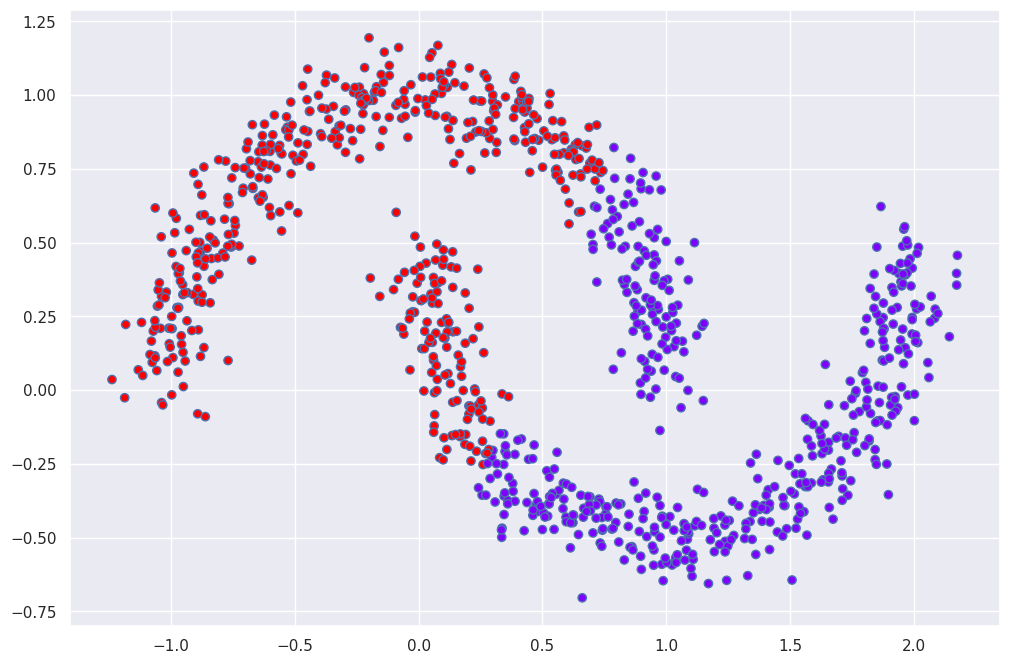

In [31]:
km = KMeans(init='k-means++', n_clusters=2)
km_clustering = km.fit(X)
plt.scatter(X[:,0], X[:,1], c=km_clustering.labels_, cmap='rainbow',edgecolors='b')

/usr/local/lib/python3.9/dist-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


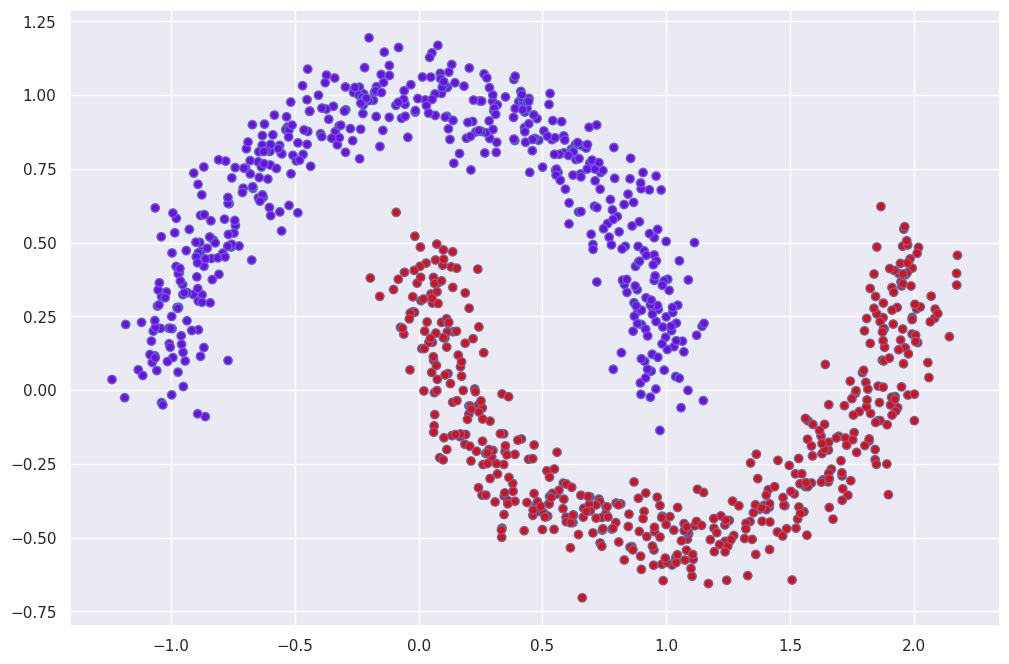

In [32]:
sc = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=0)
sc_clustering = sc.fit(X)
plt.scatter(X[:,0], X[:,1], c=sc_clustering.labels_, cmap='rainbow', edgecolors='b')

Runtime test

In [33]:
%timeit km.fit(X)

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: F

20.5 ms ± 12.7 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [25]:
%timeit sc.fit(X)

774 ms ± 433 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Implementation without SKlearn

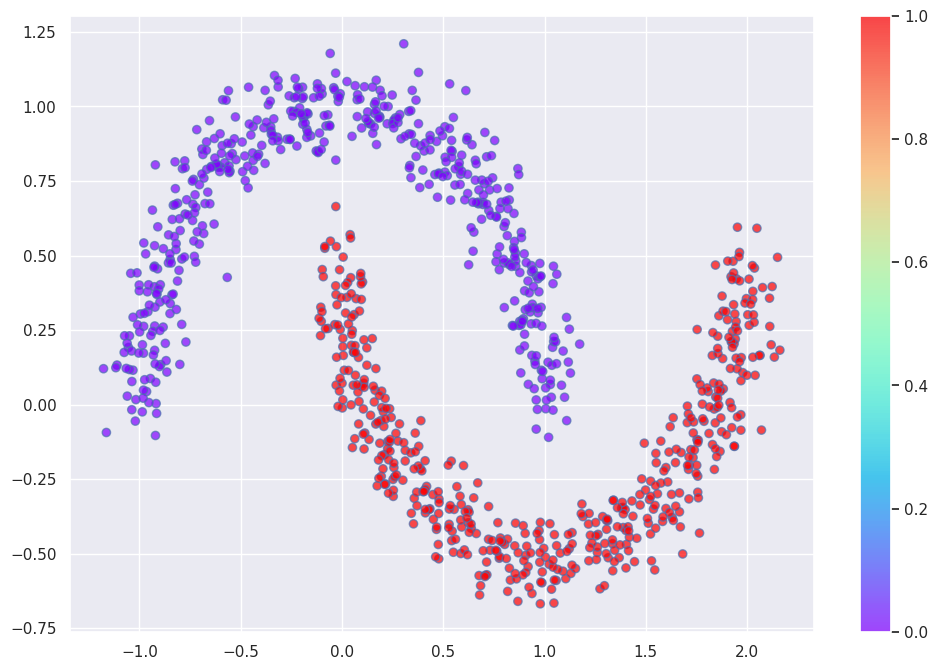

In [26]:
# contruct a graph with RBF kernel
sigma = 0.1
n = X.shape[0]
I = np.zeros((n,n), dtype=int)+np.arange(n, dtype=int)
dist = np.sum((X[I,:] - X[I.T,:])**2,axis=2)
W = np.exp(-dist/(2*sigma**2))

#Graph Laplacian
n = W.shape[0]
d = W @ np.ones(n)
L = sparse.spdiags(d,0,n,n) - W  

#Find Fiedler vector
vals, vec = sparse.linalg.eigsh(L,k=5,which='SM')
v = vec[:,1]

#Cluster labels
labels = v > 0

plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow', alpha=0.7, edgecolors='b')
plt.colorbar()

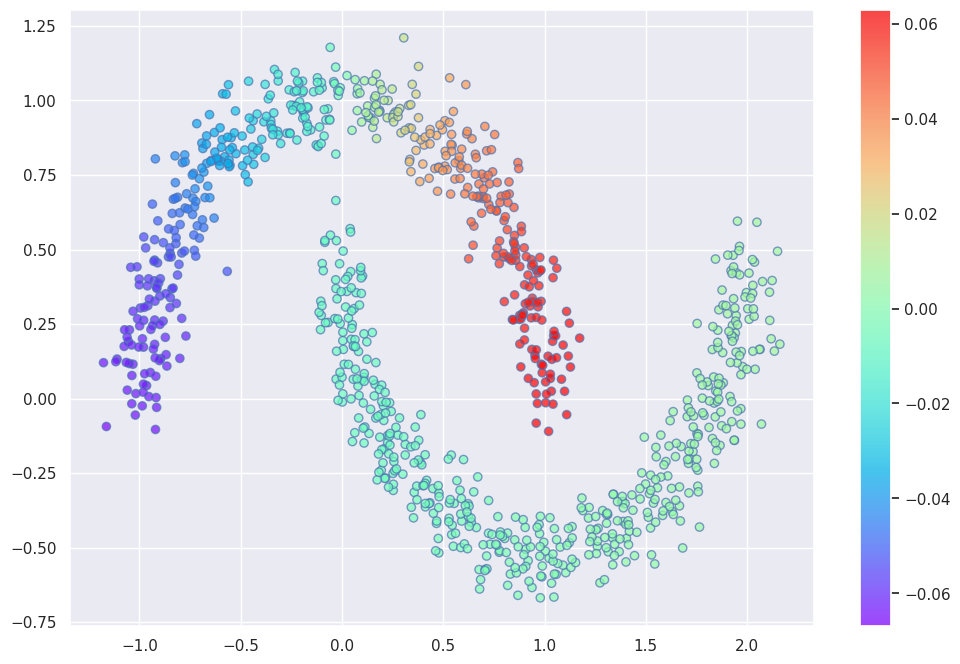

In [27]:
plt.scatter(X[:,0], X[:,1], c=vec[:,2], cmap='rainbow', alpha=0.7, edgecolors='b')
plt.colorbar()